# 03. Препроцессинг текста и формирование датасета

1. Загрузка `df_extracted.pkl`
2. Статистика по извлечённым текстам
3. Очистка: удаление титульных/служебных страниц, стоп-слов, спецсимволов
4. Фильтрация коротких документов
5. Сохранение датасета

In [1]:
import warnings
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')

OUT_DIR = Path('artifacts')
plt.rcParams['figure.figsize'] = (12, 6)

print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [2]:
df = pd.read_pickle(OUT_DIR / 'df_extracted.pkl')
print(f'Loaded {len(df)} docs')
print(f'Columns: {list(df.columns)}')
print(f'Пустых текстов (text): {(df["text_len"] == 0).sum()}')
print(f'Средняя длина текста: {df["text_len"].mean():.0f} символов')
df[['filename', 'year', 'total_pages', 'non_empty_pages', 'gap_count', 'text_len']].head(10)

Loaded 203 docs
Columns: ['path', 'filename', 'year', 'total_pages', 'non_empty_pages', 'gap_count', 'gap_indices', 'gap_reasons', 'text_pymupdf', 'text', 'text_len']
Пустых текстов (text): 0
Средняя длина текста: 62647 символов


,filename,year,total_pages,non_empty_pages,gap_count,text_len
0,Tursynbek D.Кітаптарды онлайн жалға алуды ұйым...,2019,54,46,8,44551
1,Абдикадирова А.П Косметологияда сараптамалык ж...,2019,42,37,5,68894
2,Ануарбеков А.А Интернет магазин автозапчастей ...,2019,43,36,7,42226
3,Аскаров.Е.А.Кол кимылдарын аныктау.2019.pdf,2019,43,38,5,56530
4,Ахмедова Г.У. Билимды окыту және бакылау жуйес...,2019,53,49,4,78919
5,Байгалиева Г.Е. Андроид платформасында бонусты...,2019,46,42,4,49494
6,Байдулов А.Р. Разработка интернет-магазина с и...,2019,108,106,2,132782
7,БалапанТ.Е.Ауыл шаруашылық онлайн жәрмеңкесіні...,2019,6,6,0,5360
8,БалгабайБ.М.Kazakh Life мобильді қосымшасын құ...,2019,7,6,1,4941
9,Бақытжан Берік.Мейрамхана бизнес кестесінің ав...,2019,49,44,5,79540


In [3]:
df['len_pymupdf'] = df['text_pymupdf'].str.len()
df['wc_pymupdf'] = df['text_pymupdf'].apply(lambda t: len(t.split()))
df['wc_text'] = df['text'].apply(lambda t: len(t.split()))

mets = pd.DataFrame({
    'Метод': ['PyMuPDF', 'PyMuPDF + Tesseract OCR'],
    'Средняя длина (символы)': [df['len_pymupdf'].mean(), df['text_len'].mean()],
    'Средняя длина (слова)': [df['wc_pymupdf'].mean(), df['wc_text'].mean()],
    'Пустых документов': [(df['len_pymupdf'] == 0).sum(), (df['text_len'] == 0).sum()],
})

mets

,Метод,Средняя длина (символы),Средняя длина (слова),Пустых документов
0,PyMuPDF,58936.620690,6605.266010,6
1,PyMuPDF + Tesseract OCR,62646.753695,7103.152709,0


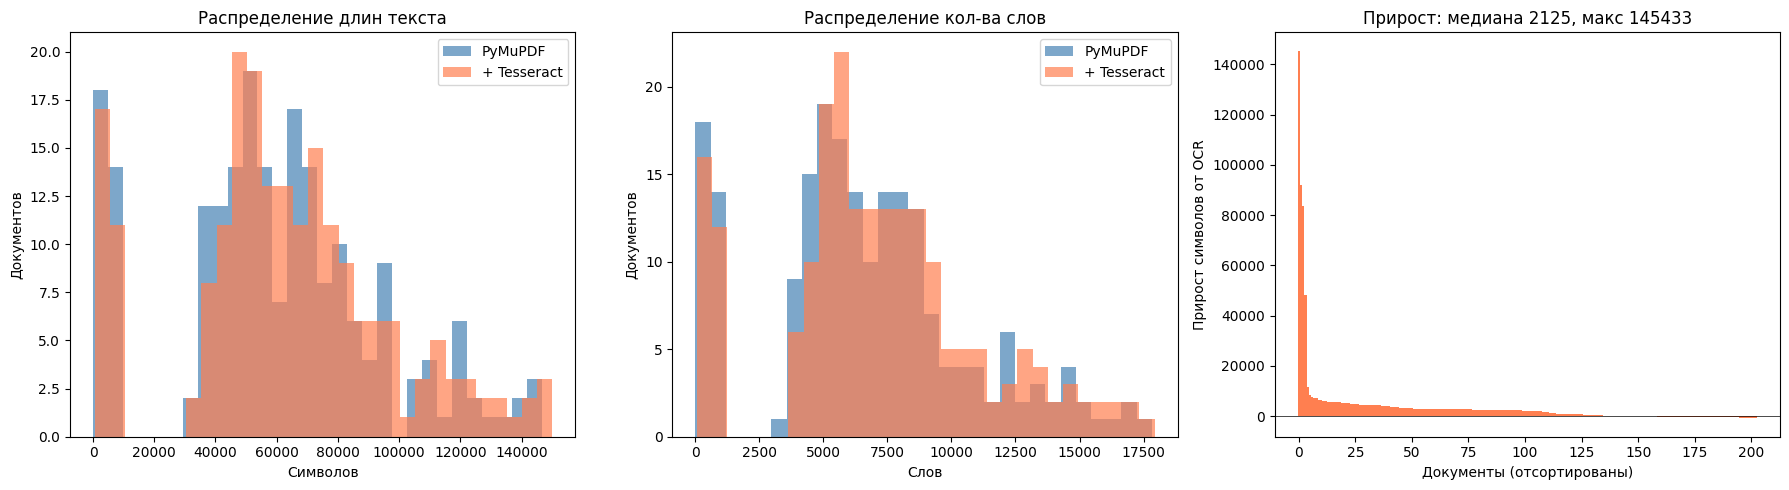

Документов с приростом от OCR: 141 из 203


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1 — Гистограмма длин
axes[0].hist(df['len_pymupdf'], bins=30, alpha=0.7, label='PyMuPDF', color='steelblue')
axes[0].hist(df['text_len'], bins=30, alpha=0.7, label='+ Tesseract', color='coral')
axes[0].set_xlabel('Символов')
axes[0].set_ylabel('Документов')
axes[0].set_title('Распределение длин текста')
axes[0].legend()

# 2 — Гистограмма кол-ва слов
axes[1].hist(df['wc_pymupdf'], bins=30, alpha=0.7, label='PyMuPDF', color='steelblue')
axes[1].hist(df['wc_text'], bins=30, alpha=0.7, label='+ Tesseract', color='coral')
axes[1].set_xlabel('Слов')
axes[1].set_ylabel('Документов')
axes[1].set_title('Распределение кол-ва слов')
axes[1].legend()

# 3 — Прирост текста от OCR
diff = df['text_len'].values - df['len_pymupdf'].values
axes[2].bar(range(len(diff)), sorted(diff, reverse=True), color='coral', width=1)
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].set_xlabel('Документы (отсортированы)')
axes[2].set_ylabel('Прирост символов от OCR')
axes[2].set_title(f'Прирост: медиана {int(np.median(diff))}, макс {int(diff.max())}')

plt.tight_layout()
plt.savefig(OUT_DIR / 'preprocessing_overview.png', dpi=150)
plt.show()

print(f'Документов с приростом от OCR: {(diff > 0).sum()} из {len(df)}')

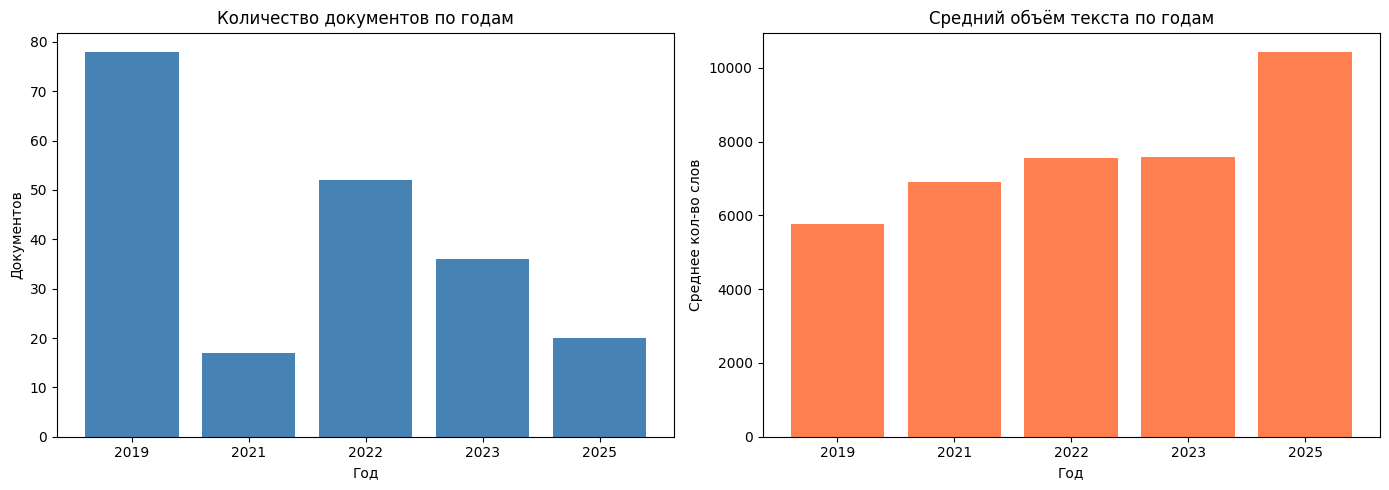

,year,docs,avg_pages,avg_len,avg_wc,gaps
0,2019,78,40.884615,52101.410256,5763.294872,377
1,2021,17,48.941176,62404.058824,6910.647059,57
2,2022,52,53.057692,66951.019231,7566.750000,188
3,2023,36,43.250000,63717.916667,7574.333333,23
4,2025,20,62.000000,90860.700000,10438.750000,223


In [ ]:
by_year = df.groupby('year').agg(
    docs=('filename', 'count'),
    avg_pages=('total_pages', 'mean'),
    avg_len=('text_len', 'mean'),
    avg_wc=('wc_text', 'mean'),
    gaps=('gap_count', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(by_year['year'].astype(str), by_year['docs'], color='steelblue')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Документов')
axes[0].set_title('Количество документов по годам')

axes[1].bar(by_year['year'].astype(str), by_year['avg_wc'], color='coral')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Среднее кол-во слов')
axes[1].set_title('Средний объём текста по годам')

plt.tight_layout()
plt.savefig(OUT_DIR / '03_year_stats.png', dpi=150)
plt.show()

by_year

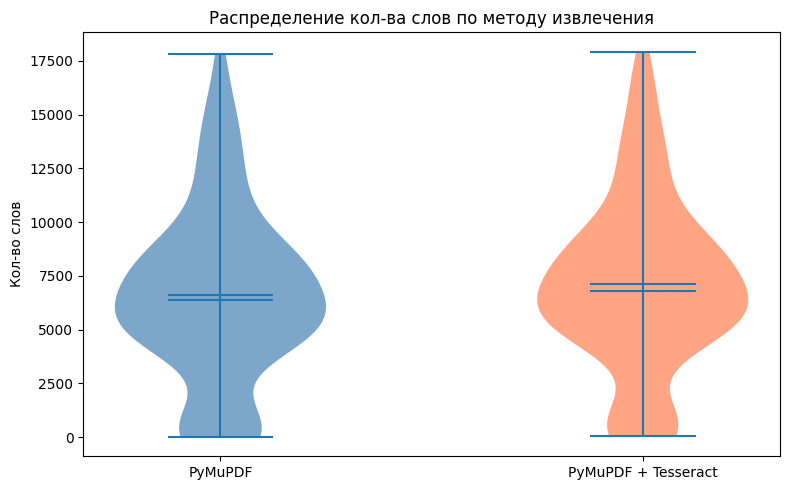

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

parts = ax.violinplot(
    [df['wc_pymupdf'].values, df['wc_text'].values],
    showmeans=True, showmedians=True
)
colors = ['steelblue', 'coral']
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c)
    pc.set_alpha(0.7)

ax.set_xticks([1, 2])
ax.set_xticklabels(['PyMuPDF', 'PyMuPDF + Tesseract'])
ax.set_ylabel('Кол-во слов')
ax.set_title('Распределение кол-ва слов по методу извлечения')

plt.tight_layout()
plt.savefig(OUT_DIR / '04_violin.png', dpi=150)
plt.show()

In [ ]:
df['text_best'] = df['text']
df['len_best'] = df['text_best'].str.len()
df['wc_best'] = df['text_best'].apply(lambda t: len(t.split()))

improved = (df['text_len'] > df['len_pymupdf']).sum()
print(f'Документов, улучшенных OCR: {improved} из {len(df)}')
print(f'Средняя длина best текста: {df["len_best"].mean():.0f} симв., {df["wc_best"].mean():.0f} слов')

Документов, улучшенных OCR: 141 из 203
Средняя длина best текста: 62647 симв., 7103 слов


In [ ]:
import pickle

ckpt_pages = pickle.loads((OUT_DIR / 'ckpt_pymupdf.pkl').read_bytes())
ckpt_ocr   = pickle.loads((OUT_DIR / 'ckpt_ocr_tess.pkl').read_bytes())

BOILER_PATS = [
    r'қазақстан\s+республикасы',
    r'министрлігі|министрлiгi',
    r'сәтбаев\s+университет|satbayev\s+university',
    r'бекітемін|бекiтемiн',
    r'қорғауға\s+жіберілді',
    r'ғылыми\s+жетекшінің\s+сын',
    r'программалық\s+инженерия\s+кафедрасы',
    r'отчет\s+подобия',
    r'scanned\s+with',
]

ABSTRACT_PATS = [r'аңдатпа', r'аннотация', r'\bannotation\b', r'\babstract\b']
TOC_PATS      = [r'мазмұны', r'содержание', r'table\s+of\s+contents']

BIBLIO_PATS   = [
    r'пайдаланылған\s+әдебиеттер',
    r'список\s+(использованн|литератур)',
    r'\bbibliography\b',
    r'\breferences\b',
]
APPENDIX_PATS = [
    r'(?:^|\n)\s*қосымша(?:лар)?\s*[а-дА-ДA-D1-9]',
    r'(?:^|\n)\s*қосымшалар\s*$',
    r'(?:^|\n)\s*приложени[ея]',
    r'(?:^|\n)\s*appendix\b',
]

MIN_CHARS  = 30
HEADER_LEN = 500


def get_merged_pages(path):
    info = ckpt_pages[path]
    pages = info['pages']
    ocr_data = ckpt_ocr.get(path, {})

    row = df.loc[df['path'] == path]
    gap_set = set(row.iloc[0]['gap_indices']) if len(row) else set()

    merged = []
    for i, pg in enumerate(pages):
        pymupdf_text = (pg.get('text') or '').strip()
        ocr_text = str(ocr_data.get(i, '')).strip()
        if i in gap_set and len(ocr_text) > MIN_CHARS:
            merged.append(ocr_text)
        elif len(pymupdf_text) < MIN_CHARS and len(ocr_text) > MIN_CHARS:
            merged.append(ocr_text)
        else:
            merged.append(pymupdf_text)
    return merged


def extract_body(pages):
    n = len(pages)
    if n == 0:
        return ""

    end_idx = n
    search_from = max(n // 2, 5)
    for i in range(n - 1, search_from - 1, -1):
        header = pages[i].lower().strip()[:HEADER_LEN]
        if len(header) < MIN_CHARS:
            continue
        if any(re.search(p, header) for p in BIBLIO_PATS):
            end_idx = i
            break
        if any(re.search(p, header, re.MULTILINE) for p in APPENDIX_PATS):
            end_idx = i
            break

    max_front_skip = min(10, n // 3 + 1)
    skip_set = set()
    for i in range(min(max_front_skip, end_idx)):
        text = pages[i].strip()
        if len(text) < MIN_CHARS:
            skip_set.add(i)
            continue
        header = text.lower()[:HEADER_LEN]
        if any(re.search(p, header) for p in BOILER_PATS + ABSTRACT_PATS + TOC_PATS):
            skip_set.add(i)

    body_parts = []
    for i in range(end_idx):
        if i in skip_set:
            continue
        text = pages[i].strip()
        if len(text) < MIN_CHARS:
            continue
        body_parts.append(text)

    return "\n".join(body_parts)


bodies = []
stats = []
for _, row in df.iterrows():
    merged = get_merged_pages(row['path'])
    body = extract_body(merged)
    bodies.append(body)

    total = len(merged)
    kept = sum(1 for p in body.split("\n") if len(p.strip()) > MIN_CHARS) if body else 0
    stats.append({'total': total, 'kept_approx': kept})

df['text_body'] = bodies
df['len_body'] = df['text_body'].str.len()
df['wc_body'] = df['text_body'].apply(lambda t: len(t.split()) if t else 0)

stats_df = pd.DataFrame(stats)
kept = stats_df['kept_approx'].sum()
removed = stats_df['total'].sum() - kept
print(f"Страниц всего:     {stats_df['total'].sum()}")
print(f"Страниц убрано:    ~{removed} (title, abstract, TOC, bibliography, appendix)")
print(f"Страниц оставлено: ~{kept}")
print(f"\nПустых после фильтрации: {(df['wc_body'] == 0).sum()}")
print(f"Средний объём тела: {df['wc_body'].mean():.0f} слов")

empty_body = df[(df['wc_body'] == 0) & (df['text_len'] > 1000)]
if len(empty_body):
    print(f"\n⚠ {len(empty_body)} документов с text_len > 1000, но wc_body = 0:")
    print(empty_body[['filename', 'total_pages', 'text_len']].to_string(index=False))

Страниц всего:     9577
Страниц убрано:    ~-116848 (title, abstract, TOC, bibliography, appendix)
Страниц оставлено: ~126425

Пустых после фильтрации: 1
Средний объём тела: 5612 слов


In [9]:
nltk.download('stopwords', quiet=True)

STOP = (
    set(stopwords.words('russian')) |
    set(stopwords.words('english')) |
    set(stopwords.words('kazakh'))
)

print(f"Стоп-слова: {len(stopwords.words('russian'))} ru + "
      f"{len(stopwords.words('english'))} en + "
      f"{len(stopwords.words('kazakh'))} kz = {len(STOP)} уникальных")


def clean(text):
    """Очистка текста: удаление спецсимволов, стоп-слов, коротких токенов."""
    text = text.lower()
    text = re.sub(r"[^0-9a-zа-яәіңғүұқөһё\s]", ' ', text)
    tokens = [w for w in text.split() if w not in STOP and len(w) > 1]
    return re.sub(r'\s+', ' ', ' '.join(tokens)).strip()


df['clean_text'] = df['text_body'].apply(clean)
df['clean_wc'] = df['clean_text'].apply(lambda t: len(t.split()) if t else 0)

print(f'\nМин: {df["clean_wc"].min()}, Макс: {df["clean_wc"].max()}, Среднее: {df["clean_wc"].mean():.0f}')
df[['filename', 'year', 'wc_body', 'clean_wc']].head(10)

Стоп-слова: 151 ru + 198 en + 324 kz = 622 уникальных

Мин: 0, Макс: 12969, Среднее: 4688


,filename,year,wc_body,clean_wc
0,Tursynbek D.Кітаптарды онлайн жалға алуды ұйым...,2019,2774,2579
1,Абдикадирова А.П Косметологияда сараптамалык ж...,2019,6122,5517
2,Ануарбеков А.А Интернет магазин автозапчастей ...,2019,3981,3161
3,Аскаров.Е.А.Кол кимылдарын аныктау.2019.pdf,2019,5828,5270
4,Ахмедова Г.У. Билимды окыту және бакылау жуйес...,2019,7402,6791
5,Байгалиева Г.Е. Андроид платформасында бонусты...,2019,3331,2943
6,Байдулов А.Р. Разработка интернет-магазина с и...,2019,12442,10424
7,БалапанТ.Е.Ауыл шаруашылық онлайн жәрмеңкесіні...,2019,652,619
8,БалгабайБ.М.Kazakh Life мобильді қосымшасын құ...,2019,710,569
9,Бақытжан Берік.Мейрамхана бизнес кестесінің ав...,2019,7711,7060


Документы с <200 слов после очистки: 9
                                                                                                             filename year  total_pages  clean_wc
ЕргешБ.К.Кирилицамен жазылған қазақ тіліндегі мәтіндерді латын әліпбиіне аударатын мобильді қосымша дайындау.2019.pdf 2019            6       170
                                                                                    справка 2023 Айнабаев Азамат.pdf 2023            1       111
                                                                                         Справка 2023 Айгожиной Э.pdf 2023            1        80
                                                                                       справка 2023 Женисов Айдос.pdf 2023            1        86
                                                                                     Справка 2023 Мамбетов Нурбол.pdf 2023            1         0
                                                                                     

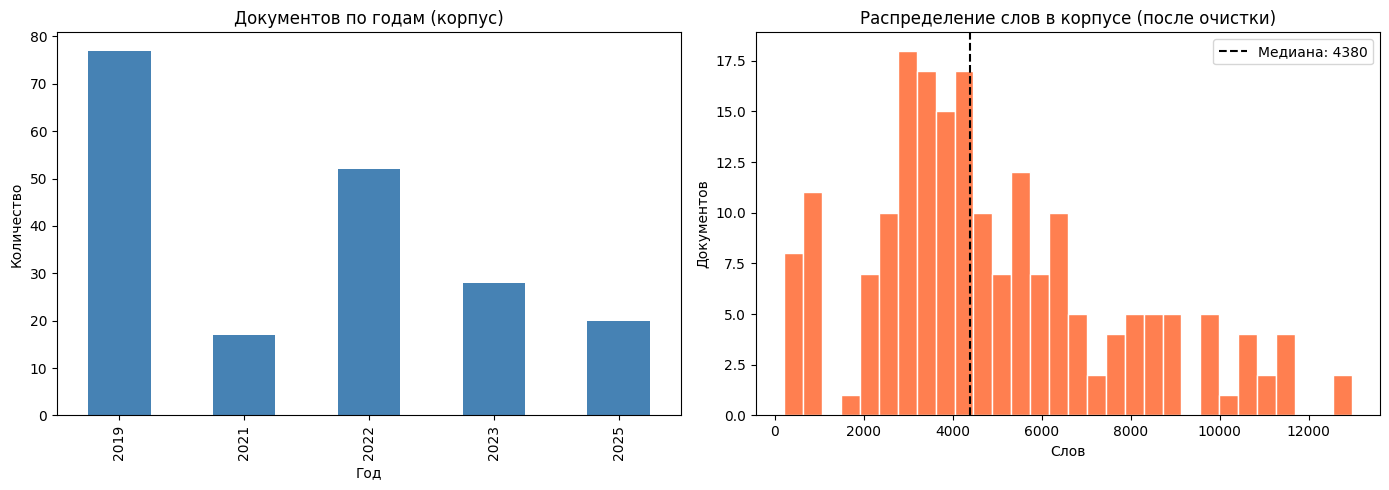

In [10]:
LOW = 200

low = df[df['clean_wc'] < LOW]
print(f'Документы с <{LOW} слов после очистки: {len(low)}')

if len(low):
    print(low[['filename', 'year', 'total_pages', 'clean_wc']].to_string(index=False))

df_corpus = df[df['clean_wc'] >= LOW].reset_index(drop=True)
print(f'\nКорпус после фильтрации: {len(df_corpus)} документов')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_corpus['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Документов по годам (корпус)')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Количество')

axes[1].hist(df_corpus['clean_wc'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(df_corpus['clean_wc'].median(), color='k', linestyle='--',
                label=f'Медиана: {df_corpus["clean_wc"].median():.0f}')
axes[1].set_title('Распределение слов в корпусе (после очистки)')
axes[1].set_xlabel('Слов')
axes[1].set_ylabel('Документов')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / '05_corpus.png', dpi=150)
plt.show()

In [ ]:
df.to_pickle(OUT_DIR / 'df_full_preprocessed.pkl')
print(f'df_full_preprocessed.pkl  ({len(df)} docs)')

corpus_cols = [
    'path', 'filename', 'year', 'total_pages',
    'text_pymupdf', 'text_body', 'clean_text',
    'clean_wc', 'len_pymupdf', 'text_len', 'len_body',
    'wc_pymupdf', 'wc_text', 'wc_body'
]
corpus_cols = [c for c in corpus_cols if c in df_corpus.columns]

df_corpus[corpus_cols].to_pickle(OUT_DIR / 'df_corpus_ready.pkl')
print(f'df_corpus_ready.pkl      ({len(df_corpus)} docs, {len(corpus_cols)} cols)')

df_corpus[['filename', 'year', 'clean_wc', 'clean_text']].to_csv(
    OUT_DIR / 'corpus_texts.csv',
    index=False,
    encoding='utf-8-sig'
)
print(f'corpus_texts.csv         ({len(df_corpus)} docs)')

print(f'\nСтолбцы: {corpus_cols}')

df_full_preprocessed.pkl  (203 docs)
df_corpus_ready.pkl      (194 docs, 14 cols)
corpus_texts.csv         (194 docs)

Столбцы: ['path', 'filename', 'year', 'total_pages', 'text_pymupdf', 'text_body', 'clean_text', 'clean_wc', 'len_pymupdf', 'text_len', 'len_body', 'wc_pymupdf', 'wc_text', 'wc_body']
